In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузка данных...
 Обучающая выборка: (60000, 28, 28)
 Тестовая выборка: (10000, 28, 28)


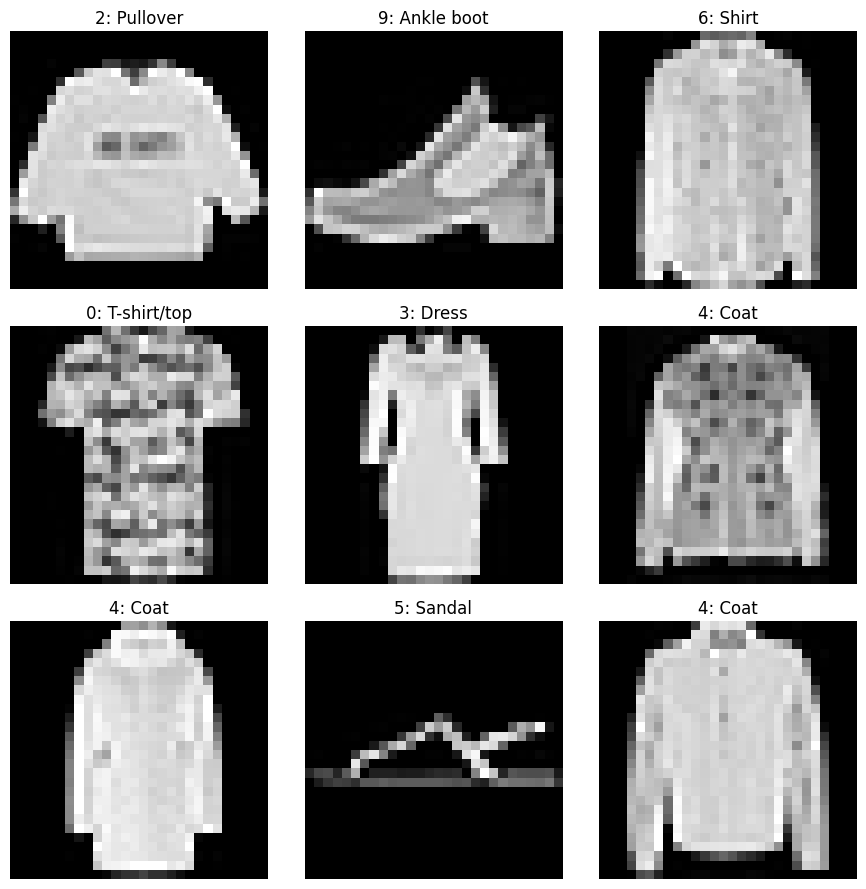

In [ ]:
FOLDER_PATH = '/content/drive/MyDrive/fashion_mnist_data/'

print("Загрузка данных...")
train_df = pd.read_csv(FOLDER_PATH + 'fashion-mnist_train.csv')
test_df = pd.read_csv(FOLDER_PATH + 'fashion-mnist_test.csv')

y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)

print(f" Обучающая выборка: {X_train.shape}")
print(f" Тестовая выборка: {X_test.shape}")

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"{y_train[i]}: {classes[y_train[i]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Data separation")
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
X_train_final, X_test_baseline, y_train_final, y_test_baseline = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)
print(f"Train: {X_train_final.shape}, Val: {X_val.shape}, Test: {X_test_baseline.shape}")

Data separation
Train: (48006, 28, 28), Val: (6000, 28, 28), Test: (5994, 28, 28)


In [ ]:
X_train_tensor = torch.tensor(X_train_final.reshape(-1, 784), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.reshape(-1, 784), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_baseline.reshape(-1, 784), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_baseline, dtype=torch.long)

In [ ]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(MLPBaseline, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLPBaseline()
print("\nModel created:")
print(model)


Model created:
MLPBaseline(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 20
train_losses = []
val_losses = []
val_accuracies = []

print("\nНачинаем обучение\n")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


Начинаем обучение

Epoch  1/20 | Train Loss: 0.5737 | Val Loss: 0.4453 | Val Acc: 84.23%
Epoch  2/20 | Train Loss: 0.4230 | Val Loss: 0.4235 | Val Acc: 84.90%
Epoch  3/20 | Train Loss: 0.3788 | Val Loss: 0.3852 | Val Acc: 86.00%
Epoch  4/20 | Train Loss: 0.3516 | Val Loss: 0.3651 | Val Acc: 86.87%
Epoch  5/20 | Train Loss: 0.3287 | Val Loss: 0.3676 | Val Acc: 86.47%
Epoch  6/20 | Train Loss: 0.3134 | Val Loss: 0.3516 | Val Acc: 87.42%
Epoch  7/20 | Train Loss: 0.2973 | Val Loss: 0.3537 | Val Acc: 86.83%
Epoch  8/20 | Train Loss: 0.2884 | Val Loss: 0.3298 | Val Acc: 87.78%
Epoch  9/20 | Train Loss: 0.2750 | Val Loss: 0.3394 | Val Acc: 87.85%
Epoch 10/20 | Train Loss: 0.2657 | Val Loss: 0.3306 | Val Acc: 87.73%
Epoch 11/20 | Train Loss: 0.2591 | Val Loss: 0.3398 | Val Acc: 87.52%
Epoch 12/20 | Train Loss: 0.2504 | Val Loss: 0.3220 | Val Acc: 88.22%
Epoch 13/20 | Train Loss: 0.2406 | Val Loss: 0.3261 | Val Acc: 88.23%
Epoch 14/20 | Train Loss: 0.2344 | Val Loss: 0.3281 | Val Acc: 88.13%


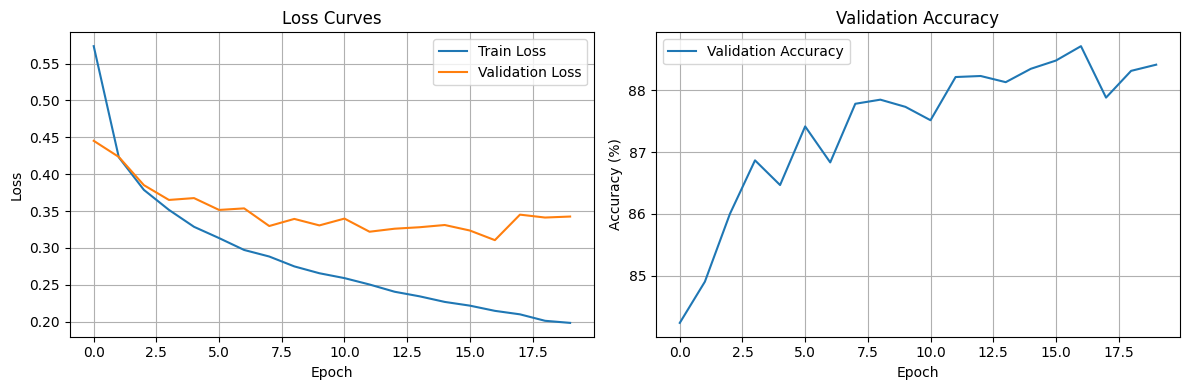

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/loss_curves.png')
plt.show()

In [ ]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n Test accuracy (accuracy): {test_accuracy:.2f}%")



 Test accuracy (accuracy): 88.86%


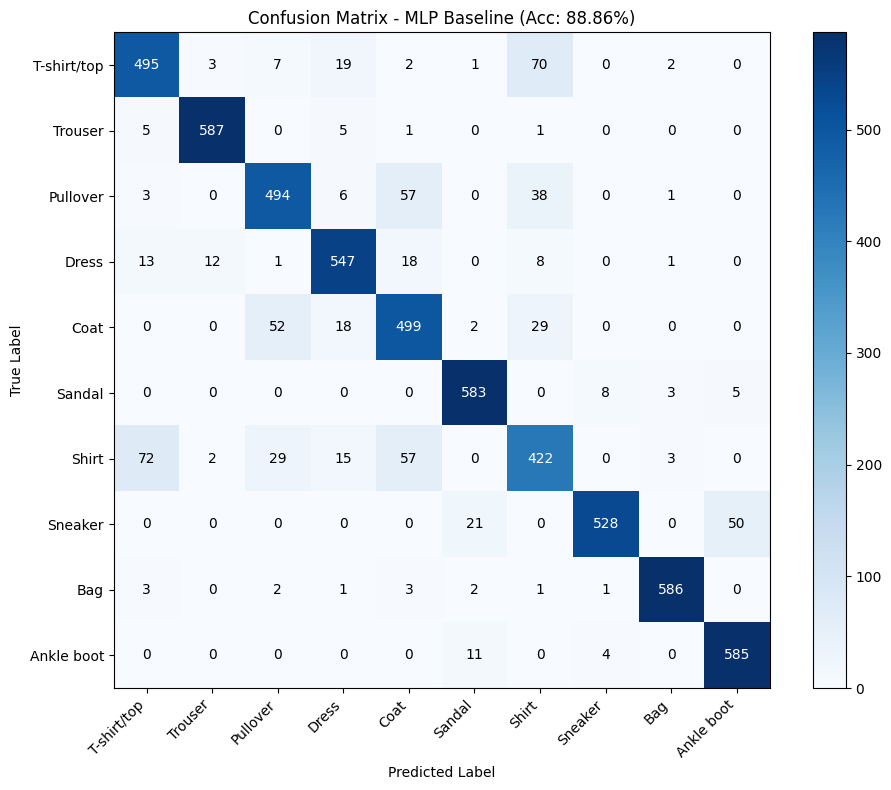

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix - MLP Baseline (Acc: {test_accuracy:.2f}%)')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right')
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png')
plt.show()

In [ ]:
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

Macro F1-Score: 0.8882
Weighted F1-Score: 0.8881


In [ ]:
from collections import Counter
errors = []
for true, pred in zip(all_labels, all_preds):
    if true != pred:
        errors.append((true, pred))

error_pairs = Counter(errors)
print("\nTop 5 most common mistakes:")
for (true, pred), count in error_pairs.most_common(5):
    print(f"  {classes[true]} → {classes[pred]}: {count} раз")


Top 5 most common mistakes:
  Shirt → T-shirt/top: 72 раз
  T-shirt/top → Shirt: 70 раз
  Pullover → Coat: 57 раз
  Shirt → Coat: 57 раз
  Coat → Pullover: 52 раз


In [ ]:
# Week 3: CNN МОДЕЛЬ ДЛЯ FASHION-MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
try:
    print(f"Данные загружены: X_train shape = {X_train.shape}")
except NameError:
    print("Ошибка: данные не найдены! Сначала выполни код загрузки Fashion-MNIST.")

Данные загружены: X_train shape = (60000, 28, 28)


In [ ]:
print("\nРазделение данных...")
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)
print(f"Train: {X_train_cnn.shape}, Val: {X_val.shape}, Test: {X_test_cnn.shape}")


Разделение данных...
Train: (48006, 28, 28), Val: (6000, 28, 28), Test: (5994, 28, 28)


In [ ]:
X_train_cnn = X_train_cnn.reshape(-1, 1, 28, 28)
X_val_cnn = X_val.reshape(-1, 1, 28, 28)
X_test_cnn = X_test_cnn.reshape(-1, 1, 28, 28)

print(f"Train shape для CNN: {X_train_cnn.shape}")

Train shape для CNN: (48006, 1, 28, 28)


In [ ]:
X_train_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_cnn, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_cnn, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_cnn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_cnn, dtype=torch.long)

In [ ]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FashionCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = FashionCNN()
print("\nCNN модель создана:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


CNN модель создана:
FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Всего параметров: 824,650
Обучаемых параметров: 824,650


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 20
train_losses = []
val_losses = []
val_accuracies = []

print("\nНачинаем обучение CNN...\n")
for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


Начинаем обучение CNN...

Epoch  1/20 | Train Loss: 0.5004 | Val Loss: 0.3168 | Val Acc: 88.62%
Epoch  2/20 | Train Loss: 0.3439 | Val Loss: 0.2661 | Val Acc: 90.32%
Epoch  3/20 | Train Loss: 0.2951 | Val Loss: 0.2586 | Val Acc: 90.85%
Epoch  4/20 | Train Loss: 0.2690 | Val Loss: 0.2693 | Val Acc: 90.25%
Epoch  5/20 | Train Loss: 0.2437 | Val Loss: 0.2516 | Val Acc: 90.77%
Epoch  6/20 | Train Loss: 0.2209 | Val Loss: 0.2373 | Val Acc: 91.38%
Epoch  7/20 | Train Loss: 0.2052 | Val Loss: 0.2413 | Val Acc: 91.38%
Epoch  8/20 | Train Loss: 0.1907 | Val Loss: 0.2246 | Val Acc: 91.93%
Epoch  9/20 | Train Loss: 0.1745 | Val Loss: 0.2299 | Val Acc: 92.07%
Epoch 10/20 | Train Loss: 0.1642 | Val Loss: 0.2318 | Val Acc: 92.17%
Epoch 11/20 | Train Loss: 0.1501 | Val Loss: 0.2333 | Val Acc: 92.20%
Epoch 12/20 | Train Loss: 0.1426 | Val Loss: 0.2464 | Val Acc: 92.17%
Epoch 13/20 | Train Loss: 0.1339 | Val Loss: 0.2456 | Val Acc: 92.45%
Epoch 14/20 | Train Loss: 0.1215 | Val Loss: 0.2613 | Val Acc: 

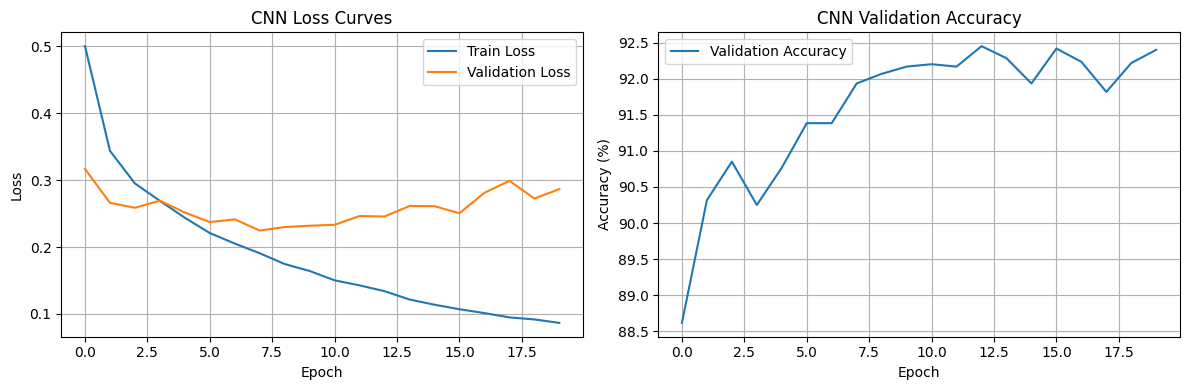

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss Curves')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('CNN Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/cnn_loss_curves.png')
plt.show()

In [ ]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n CNN Тестовая точность (accuracy): {test_accuracy:.2f}%")


 CNN Тестовая точность (accuracy): 92.98%


In [ ]:
print(f"\n Сравнение моделей:")
print(f"   MLP baseline: 88.44%")
print(f"   CNN:          {test_accuracy:.2f}%")
print(f"   Улучшение:    {test_accuracy - 88.44:.2f}%")


 Сравнение моделей:
   MLP baseline: 88.44%
   CNN:          92.98%
   Улучшение:    4.54%


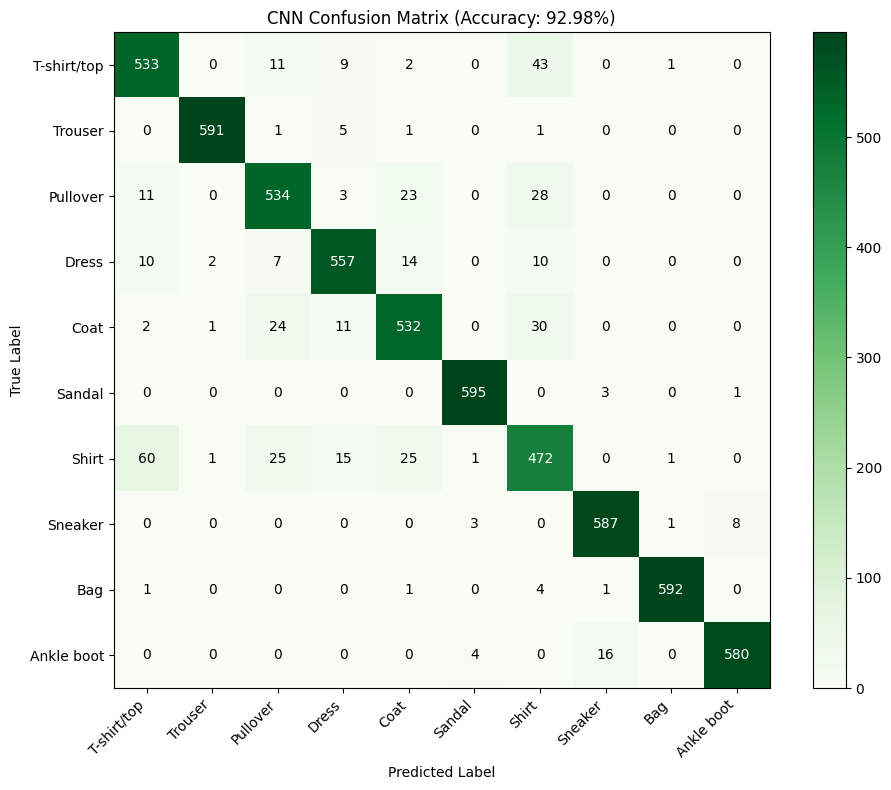

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Greens')
plt.title(f'CNN Confusion Matrix (Accuracy: {test_accuracy:.2f}%)')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right')
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('/content/cnn_confusion_matrix.png')
plt.show()

In [ ]:
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"\nMacro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")


Macro F1-Score: 0.9298
Weighted F1-Score: 0.9297


In [ ]:
from collections import Counter
errors = []
for true, pred in zip(all_labels, all_preds):
    if true != pred:
        errors.append((true, pred))

error_pairs = Counter(errors)
print("\nТоп-5 самых частых ошибок CNN:")
for (true, pred), count in error_pairs.most_common(5):
    print(f"  {classes[true]} → {classes[pred]}: {count} раз")


Топ-5 самых частых ошибок CNN:
  Shirt → T-shirt/top: 60 раз
  T-shirt/top → Shirt: 43 раз
  Coat → Shirt: 30 раз
  Pullover → Shirt: 28 раз
  Shirt → Pullover: 25 раз


In [ ]:
print("\n Сравнение ошибок (MLP vs CNN):")
print("   MLP топ-1 ошибка: Shirt → T-shirt/top (103 раза)")
print(f"   CNN топ-1 ошибка: {classes[errors[0][0]]} → {classes[errors[0][1]]} ({error_pairs.most_common(1)[0][1]} раз)" if errors else "   Нет ошибок")


 Сравнение ошибок (MLP vs CNN):
   MLP топ-1 ошибка: Shirt → T-shirt/top (103 раза)
   CNN топ-1 ошибка: Dress → Coat (60 раз)
